# DS 4400 - Assignment 02

**Student Name**: Elyssa Querubin

**Date**: 2/12/2026


### Submission Instructions
- Submit a PDF writeup named `%LASTNAME%_HW2.pdf` in Gradescope. Please answer all the questions in the PDF. If a problem asks for graphs or other results, please extract the results from the code and include them in the report. The PDF report should have complete answers to all the questions.
- The problem set contains two types of problem as noted at the beginning of the question or sub-question: (1) analytical, denoted by *[A]*; **and (2) computational, denoted by *[C]*. The response to analytical problems should show all works and derivations. The response to computational problems should contain expected results, and the code should be made available.
- Please use Jupyter notebooks in Python as we will be selectively running your code. Include comments in the code if needed. Include a link to your code in the PDF file.

### Course policy on collaboration and cheating

- You may discuss the concepts with your classmates, but write up the answers entirely on your own.
- You cannot share your code with your classmates.
- You cannot use code from the Internet or entirely generated with AI for your assignment.
- You can post questions on Piazza and are encouraged to come to the TA and Instructor office hours.

### Dataset

The dataset for this assignment is available [here](https://drive.google.com/drive/folders/1FV7qofHD_olqygrIjASLQ7k7LTyVSEGG?usp=sharing).  The prediction task is to predict the price of a house (column price) given the other features. Please ignore the columns `id` and `date`, as well as the categorical column `zipcode`. File `kc_house_data.csv` includes all the records in the dataset. The training file `train.csv` and testing file `test.csv` include each 1000 records extracted from the dataset. Please apply the following transformations to the data before using it for this homework:

- Scale the data so that each feature has mean 0 and standard deviation 1.
- Divide the price by 1000 for all rows in the dataset. This will reduce the value of MSE.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# load datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
df = pd.read_csv('kc_house_data.csv')

print("Original dataset:")
print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Full: {df.shape}")
print()

columns_to_drop = ['id', 'date', 'zipcode']

train_df = train_df.drop(columns=['zipcode'])
test_df = test_df.drop(columns=columns_to_drop)
df = df.drop(columns=columns_to_drop)

print("After dropping: ")
print(train_df.columns.tolist())

X_train = train_df.drop(columns=['price'])
y_train = train_df['price']

X_test = test_df.drop(columns=['price'])
y_test = test_df['price']

X_df = df.drop(columns=['price'])
y_df = df['price']

print("Feature columns:")
print(X_train.columns.tolist())
print()

# scale features
scaler = StandardScaler()
X_train_scaled_arr = scaler.fit_transform(X_train)
X_test_scaled_arr = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_arr, columns=X_test.columns, index=X_test.index)

print("Means: ", X_train_scaled.mean().round(10))
print()
print("Standard deviations: ", X_train_scaled.mean().round(10))
print()

# divide price by 1000
y_train_scaled = y_train / 1000
y_test_scaled = y_test / 1000

print("After dividing by 1000: ")
print(f"Training price - Min: {y_train_scaled.min():.2f}, Max: {y_train_scaled.max():.2f}, Mean: {y_train_scaled.mean():.2f}")
print(f"Test price - Min: {y_test_scaled.min():.2f}, Max: {y_test_scaled.max():.2f}, Mean: {y_test_scaled.mean():.2f}")
print()

# final dates after processing
print("After processing: ")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_train_scaled: {y_train_scaled.shape}")
print(f"y_test_scaled: {y_test_scaled.shape}")
print()
print("First 5 rows of scaled training features:")
print(X_train_scaled.head())
print()
print("First 5 rows of scaled training prices:")
print(y_train_scaled.head())

Original dataset:
Train: (1000, 20)
Test: (1000, 22)
Full: (21613, 21)

After dropping: 
['Unnamed: 0', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
Feature columns:
['Unnamed: 0', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Means:  Unnamed: 0       0.0
bedrooms        -0.0
bathrooms        0.0
sqft_living      0.0
sqft_lot         0.0
floors           0.0
waterfront       0.0
view             0.0
condition        0.0
grade            0.0
sqft_above      -0.0
sqft_basement    0.0
yr_built         0.0
yr_renovated     0.0
lat             -0.0
long            -0.0
sqft_living15   -0.0
sqft_lot15       0.0
dtype: float64

Standard deviations:  Unnamed:

# *[A]* Problem 1: Linear Regression (15 points)

Assume that we have $N=30$ samples of a feature $X$ representing the age of a person, and response $Y$ representing the income of the person. We are given the following:

- Sample mean of $X$ is $\bar{X}=50$; sample standard deviation of $X$ is $\sigma_X=10$;
- Sample mean of $Y$ is $\bar{Y} =100$; sample standard deviation of $Y$ is $\sigma_y=20$;
- The correlation coefficient between $X$ and $Y$ is $\rho =0.8$.

1. Compute the $\theta_0$ and $\theta_1$ coefficients of the least square linear regression model $h_{\theta} (x) =\theta_0 + \theta_1 x$ that predicts response $Y$ based on feature $X$
2. Change the correlation coefficient to $\rho=-0.8$. How do the parameters of the least square linear regression model change?


# q1.1

θ1 = 0.8 * 20/10 = 1.6
θ0 = 100 - 1.6 * 50 = 20
Model: H_θ(x) = 20 + 1.6x

# q1.2

ρ = -0.8
θ1 = -0.8 * 20/10 = -1.6
θ0 = 100 - (-1.6) * 50 = 180
Model: H_θ(x) = 180 - 1.6x the sign flipped for the slope and the intercept increased

# *[C]* Problem 2:  Linear regression (15 points)

In this problem, you will use an existing package of your choice for training and testing a linear regression model for the house prediction
dataset.

1. Use an existing package to train a multiple linear regression model on the training set using all the features (except the ones excluded above). Report the coefficients of the linear regression models and the following metrics on the training data: (1) MSE metric; (2) $R^2$ metric.
2. Evaluate the model on the testing set. Report the MSE and $R^2$ metrics on the testing set.
3. Interpret the results in your own words. Which features contribute mostly to the linear regression model? Is the model fitting the data well? How large is the model error? How do the training and testing MSE relate?

In [2]:
# q2.1

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# model fitting
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

coefficients = pd.DataFrame({
    'Feature' : X_train.columns,
    'Coefficient': model.coef_
})
coefficients = coefficients.sort_values('Coefficient', key=abs, ascending=False)
print("Coefficients: ")
print(f"Intercept (θ₀): {model.intercept_:.4f}")
print()
print("Feature Coefficients (θᵢ):")
print(coefficients.to_string(index=False))
print()

y_train_pred = model.predict(X_train_scaled)

mse = mean_squared_error(y_train_scaled, y_train_pred)
r2 = r2_score(y_train_scaled, y_train_pred)

print(f"MSE: {mse:.2f}")
print()
print(f"R^2: {r2:.2f}")
print()

Coefficients: 
Intercept (θ₀): 520.4148

Feature Coefficients (θᵢ):
      Feature  Coefficient
        grade    92.511076
          lat    78.129852
     yr_built   -68.043173
   waterfront    64.230911
  sqft_living    57.161582
   sqft_above    48.439051
         view    47.610288
sqft_living15    45.479128
sqft_basement    27.688812
    bathrooms    18.456913
 yr_renovated    17.341926
   sqft_lot15   -12.906560
     bedrooms   -12.807339
    condition    12.647609
     sqft_lot    11.127338
   Unnamed: 0     8.456024
       floors     8.151038
         long    -1.437669

MSE: 31415.75

R^2: 0.73



In [3]:
# q2.2

y_test_pred = model.predict(X_test_scaled)

test_mse = mean_squared_error(y_test_scaled, y_test_pred)
test_r2 = r2_score(y_test_scaled, y_test_pred)

print(f"MSE: {test_mse:.2f}")
print()
print(f"R^2: {test_r2:.2f}")
print()

MSE: 58834.67

R^2: 0.65



# q2.3

The features contributing most to the linear regression model are the grade, lat, yr_built, waterfront, and sqft_living. The grade has the largest positive impact while the yr_built being low reduces the price of the house. The model is fitting the data pretty well with the R^2 score being 0.73 and the training set being 0.65 on the test set, meaning the model explains 75% and 65% of the variance in the training and test data. The MSE on the test set is 58824.67 which is a moderate error relative to housing prices. The MSE for the training vs. test sets are 31415.75 and 58834.67, the test MSE is significantly higher meaning the there is moderatly overfitting as it perforns better on the training set than the test data. The model performs relatively well with relatively good performance in modeling the variance of the data sets, but the MSE is still moderately high for the test data in comparison to the training data.

# *[C]* Problem 3:  Implementing closed-form solution for linear regression (15 points)

In this problem, you will implement your own linear regression model, using the closed-form solution we derived in class. You will also
compare your model with the one trained with the package in Problem 2 on the same house price prediction dataset.

- Implement the closed-from solution for multiple linear regression using matrix operations and train a model on the training set. Write
a function to predict the response on a new testing point.
- Compare the models given by your implementation with those trained in Problem 2 by the Python packages. Report the MSE and $R^2$
metrics for the models you implemented on both training and testing sets and compare these metrics to the ones given by the package
implementation from Problem 2. Discuss if the results of your implementation are similar to those of the package.

In [4]:
def train_linear_regression_closed_form(X, y):

    n_samples = X.shape[0]
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X])
    
    X_transpose = X_with_intercept.T
    theta = np.linalg.inv(X_transpose @ X_with_intercept) @ X_transpose @ y
    
    return theta


def predict_linear_regression(X, theta):
    # add col of ones for intercept term
    n_samples = X.shape[0]
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X])
    
    # pred: y = X @ θ
    y_pred = X_with_intercept @ theta
    
    return y_pred


# train the model using closed-form solution
theta = train_linear_regression_closed_form(X_train_scaled, y_train_scaled.values)

# intercept and coefficients
intercept = theta[0]
coefficients = theta[1:]

print("Coefficients:")
print(f"Intercept (θ₀): {intercept:.2f}")
print()
print("Feature Coefficients:")

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))
print()

# predictions on training set
y_train_pred = predict_linear_regression(X_train_scaled, theta)

# Calculate metrics on training set
train_mse_custom = mean_squared_error(y_train_scaled, y_train_pred)
train_r2_custom = r2_score(y_train_scaled, y_train_pred)

print(f"MSE: {train_mse_custom:.2f}")
print(f"R^2:  {train_r2_custom:.2f}")

# predictions on test set
y_test_pred_custom = predict_linear_regression(X_test_scaled, theta)

# calc on test set
test_mse_custom = mean_squared_error(y_test_scaled, y_test_pred_custom)
test_r2_custom = r2_score(y_test_scaled, y_test_pred_custom)

print("Test Set Metrics:")
print(f"MSE: {test_mse_custom:.2f}")
print(f"R^2:  {test_r2_custom:.2f}")
print()

Coefficients:
Intercept (θ₀): 520.41

Feature Coefficients:
      Feature  Coefficient
   sqft_above   157.326155
sqft_basement   135.113318
        grade   107.460147
          lat    78.129852
   waterfront    68.154209
     yr_built   -68.043173
  sqft_living   -66.717515
     bedrooms   -47.131387
sqft_living15    45.479128
       floors    40.024759
         view    33.277047
    bathrooms    29.797239
     sqft_lot    21.118418
 yr_renovated    17.341926
   sqft_lot15   -12.906560
    condition    10.502644
   Unnamed: 0     5.296360
         long    -1.437669

MSE: 34512.15
R^2:  0.70
Test Set Metrics:
MSE: 57870.90
R^2:  0.65



In [5]:
# sklearn model
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_scaled, y_train_scaled)

# predictions
y_train_pred_sklearn = model_sklearn.predict(X_train_scaled)
y_test_pred_sklearn = model_sklearn.predict(X_test_scaled)

# metrics
train_mse_sklearn = mean_squared_error(y_train_scaled, y_train_pred_sklearn)
train_r2_sklearn = r2_score(y_train_scaled, y_train_pred_sklearn)
test_mse_sklearn = mean_squared_error(y_test_scaled, y_test_pred_sklearn)
test_r2_sklearn = r2_score(y_test_scaled, y_test_pred_sklearn)

print("Sklearn:")
print(f"Intercept (θ₀): {model_sklearn.intercept_:.2f}")
print()
print("Training Set Metrics:")
print(f"  MSE: {train_mse_sklearn:.2f}")
print(f"  R^2:  {train_r2_sklearn:.2f}")
print()
print("Test Set Metrics:")
print(f"  MSE: {test_mse_sklearn:.2f}")
print(f"  R^2:  {test_r2_sklearn:.2f}")
print()

Sklearn:
Intercept (θ₀): 520.41

Training Set Metrics:
  MSE: 31415.75
  R^2:  0.73

Test Set Metrics:
  MSE: 58834.67
  R^2:  0.65



The two implementations actually do not differ that much at all, the test data R^2 metric is the same for both while the R^2 for the training data differs by 0.03. The MSE for training data differ by 3,096.40 and the test MSEs differ by 963.77. Meaning the perform relatively similar with sklearn's linear regression model performing slightly better.

# *[C]* Problem 4: Polynomial Regression (15 points)

- Consider a feature $X$, a response variable $Y$, and $N$ samples of training data. Implement a polynomial regression model that fits a polynomial of degree $p$ to the data using the least-square method. Use your own implementation from Problem 3 and adapt it for polynomial
regression. If $p=2$, the model will use two features ($X$ and $X^2$), if $p=3$ the model will use 3 features ($X,X^2,X^3$), and so on for larger values of $p$.
- Consider the house price prediction problem with feature $X=$ `sqft_living`. Train a polynomial regression model for different values of $p \le 5$ using your implementation. Include a table with the MSE and $R^2$ metrics on both the training and testing data for at least 3 different values of $p$. Discuss your observations on how the MSE and $R^2$ metrics change with the degree of the polynomial.

  Training - MSE: 57947.53, R^2: 0.50
  Test     - MSE: 88575.98, R^2: 0.47

  Training - MSE: 54822.67, R^2: 0.52
  Test     - MSE: 71791.68, R^2: 0.57

  Training - MSE: 53785.19, R^2: 0.53
  Test     - MSE: 99833.48, R^2: 0.40

  Training - MSE: 52795.77, R^2: 0.54
  Test     - MSE: 250979.27, R^2: -0.51

  Training - MSE: 52626.11, R^2: 0.54
  Test     - MSE: 570616.91, R^2: -2.42

 Degree (p)    Train MSE  Train R^2      Test MSE  Test R^2
          1 57947.526161   0.496709  88575.978543  0.468736
          2 54822.665116   0.523849  71791.679479  0.569406
          3 53785.194716   0.532860  99833.483763  0.401216
          4 52795.774758   0.541453 250979.274285 -0.505331
          5 52626.111955   0.542927 570616.914821 -2.422464



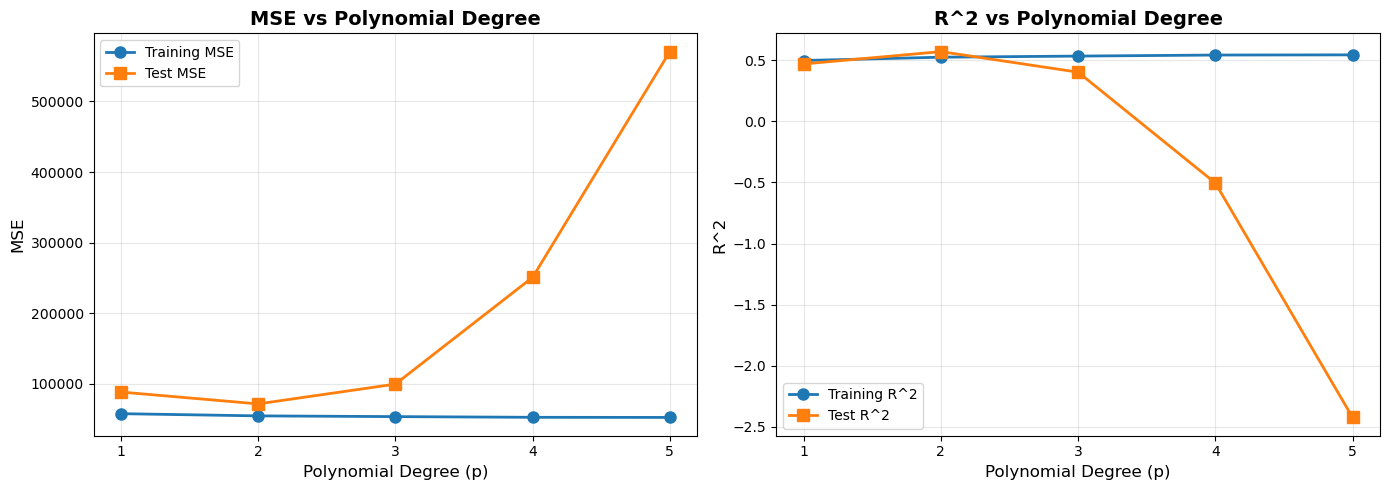

In [6]:
import matplotlib.pyplot as plt

def create_polynomial_features(X, degree):
    # Ensure X is 2D
    if len(X.shape) == 1:
        X = X.reshape(-1, 1)
    
    n_samples = X.shape[0]
    X_poly = np.zeros((n_samples, degree))
    
    for i in range(1, degree + 1):
        X_poly[:, i-1] = (X[:, 0] ** i)
    
    return X_poly


def train_polynomial_regression(X, y, degree):
    # polynomial features
    X_poly = create_polynomial_features(X, degree)
    
    # intercept term
    n_samples = X_poly.shape[0]
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X_poly])
    
    # Closed-form solution: θ = (X^T X)^(-1) X^T y
    X_transpose = X_with_intercept.T
    theta = np.linalg.inv(X_transpose @ X_with_intercept) @ X_transpose @ y
    
    return theta


def predict_polynomial_regression(X, theta, degree):
    # poly features
    X_poly = create_polynomial_features(X, degree)
    
    #intercept term
    n_samples = X_poly.shape[0]
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X_poly])
    
    # pred: y = X @ θ
    y_pred = X_with_intercept @ theta
    
    return y_pred


X_train_sqft = train_df['sqft_living'].values
X_test_sqft = test_df['sqft_living'].values

X_train_scaled = scaler.fit_transform(X_train_sqft.reshape(-1, 1)).flatten()
X_test_scaled = scaler.transform(X_test_sqft.reshape(-1, 1)).flatten()

y_train = train_df['price'].values / 1000
y_test = test_df['price'].values / 1000

# test different poly degrees
degrees = [1, 2, 3, 4, 5]
results = []

for p in degrees:
    
    # train model
    theta = train_polynomial_regression(X_train_scaled, y_train, degree=p)
    
    # pred on training set
    y_train_pred = predict_polynomial_regression(X_train_scaled, theta, degree=p)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # pred on test set
    y_test_pred = predict_polynomial_regression(X_test_scaled, theta, degree=p)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # store results
    results.append({
        'Degree (p)': p,
        'Train MSE': train_mse,
        'Train R^2': train_r2,
        'Test MSE': test_mse,
        'Test R^2': test_r2
    })
    
    print(f"  Training - MSE: {train_mse:.2f}, R^2: {train_r2:.2f}")
    print(f"  Test     - MSE: {test_mse:.2f}, R^2: {test_r2:.2f}")
    print()


results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE
axes[0].plot(results_df['Degree (p)'], results_df['Train MSE'], 
             marker='o', label='Training MSE', linewidth=2, markersize=8)
axes[0].plot(results_df['Degree (p)'], results_df['Test MSE'], 
             marker='s', label='Test MSE', linewidth=2, markersize=8)
axes[0].set_xlabel('Polynomial Degree (p)', fontsize=12)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('MSE vs Polynomial Degree', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(degrees)

# R^2
axes[1].plot(results_df['Degree (p)'], results_df['Train R^2'], 
             marker='o', label='Training R^2', linewidth=2, markersize=8)
axes[1].plot(results_df['Degree (p)'], results_df['Test R^2'], 
             marker='s', label='Test R^2', linewidth=2, markersize=8)
axes[1].set_xlabel('Polynomial Degree (p)', fontsize=12)
axes[1].set_ylabel('R^2', fontsize=12)
axes[1].set_title('R^2 vs Polynomial Degree', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(degrees)

plt.tight_layout()
plt.show()

The higher the polynomial degree the higher the test MSE became, while the higher the polynomial degree in R62, the lower R^2 became. MSE has a slight U curve which indidcates it is overfitting, R^2 indicates overfitting at p=3 and continues to overfit the higher p gets. p=1 is too simple for capturing the relationship, p=2 is optimal for both R^2 and MSE.

# *[C]* Problem 5:  Gradient descent (20 points)

In this problem, you will implement your own gradient descent algorithm and apply it to linear regression on the same house prediction dataset.

1. Write code for gradient descent for training linear regression using the algorithm from class.
2. Vary the value of the learning rate (at least 3 different values $\alpha \in \{0.01,0.1,0.5\}$) and report the value of the model parameter $\theta$ after different number of iterations (10, 50, and 100). Include in a table the MSE and $R^2$ metrics on the training and testing set for the different number of iterations and different learning rates. You can choose more values of the learning rates to observe how the  behavior of the algorithm changes.
3. Write some observations about the behavior of the algorithm: How do the metrics change with different learning rates; How many iterations are needed; Does the algorithm converge to the optimal solution, etc.

In [7]:
def compute_cost(X, y, theta):
    n_samples = X.shape[0]
    
    # add intercept column
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X])
    
    # pred
    predictions = X_with_intercept @ theta
    
    # MSE cost
    cost = (1 / (2 * n_samples)) * np.sum((predictions - y) ** 2)
    
    return cost


def compute_gradient(X, y, theta):
    n_samples = X.shape[0]
    
    # add intercept column
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X])
    
    # pred
    predictions = X_with_intercept @ theta
    
    # gradient: (1/n) * X^T * (predictions - y)
    gradient = (1 / n_samples) * X_with_intercept.T @ (predictions - y)
    
    return gradient


def gradient_descent(X, y, learning_rate, num_iterations, verbose=False):
    n_features = X.shape[1]
    
    # theta to zeros
    theta = np.zeros(n_features + 1)
    
    # cost and theta history
    cost_history = []
    theta_history = {}
    
    # grad descent
    for i in range(num_iterations):
        # compute
        gradient = compute_gradient(X, y, theta)
        
        # update theta
        theta = theta - learning_rate * gradient
        
        # comp cost
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        
        # history of theta
        if i + 1 in [10, 50, 100] or i + 1 == num_iterations:
            theta_history[i + 1] = theta.copy()
        
        # print
        if verbose and (i + 1) % 10 == 0:
            print(f"  Iteration {i+1}: Cost = {cost:.2f}")
    
    return theta, cost_history, theta_history


def predict(X, theta):
    n_samples = X.shape[0]
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X])
    
    return X_with_intercept @ theta


# just in case df's are affected by prev problem

# load data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df = train_df.drop(columns=['zipcode'], errors='ignore')
test_df = test_df.drop(columns=['id', 'date', 'zipcode'], errors='ignore')


X_train = train_df.drop(columns=['price']).values
y_train = train_df['price'].values / 1000

X_test = test_df.drop(columns=['price']).values
y_test = test_df['price'].values / 1000

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples: {X_test_scaled.shape[0]}")
print(f"Number of features: {X_train_scaled.shape[1]}")
print()


Training samples: 1000
Test samples: 1000
Number of features: 18



  Iteration 10:
    Train MSE: 374637.15, Train R^2: -2.25
    Test MSE: 446769.12, Test R^2: -1.68
    Cost: 187318.57
  Iteration 50:
    Train MSE: 335054.92, Train R^2: -1.91
    Test MSE: 400034.20, Test R^2: -1.40
    Cost: 167527.46
  Iteration 100:
    Train MSE: 295492.40, Train R^2: -1.57
    Test MSE: 353330.86, Test R^2: -1.12
    Cost: 147746.20

  Iteration 10:
    Train MSE: 294796.69, Train R^2: -1.56
    Test MSE: 352448.96, Test R^2: -1.11
    Cost: 147398.35
  Iteration 50:
    Train MSE: 138298.52, Train R^2: -0.20
    Test MSE: 170450.93, Test R^2: -0.02
    Cost: 69149.26
  Iteration 100:
    Train MSE: 70094.38, Train R^2: 0.39
    Test MSE: 94751.22, Test R^2: 0.43
    Cost: 35047.19

  Iteration 10:
    Train MSE: 66473.61, Train R^2: 0.42
    Test MSE: 90873.01, Test R^2: 0.45
    Cost: 33236.81
  Iteration 50:
    Train MSE: 31510.72, Train R^2: 0.73
    Test MSE: 58929.63, Test R^2: 0.65
    Cost: 15755.36
  Iteration 100:
    Train MSE: 31427.50, Train R^2:

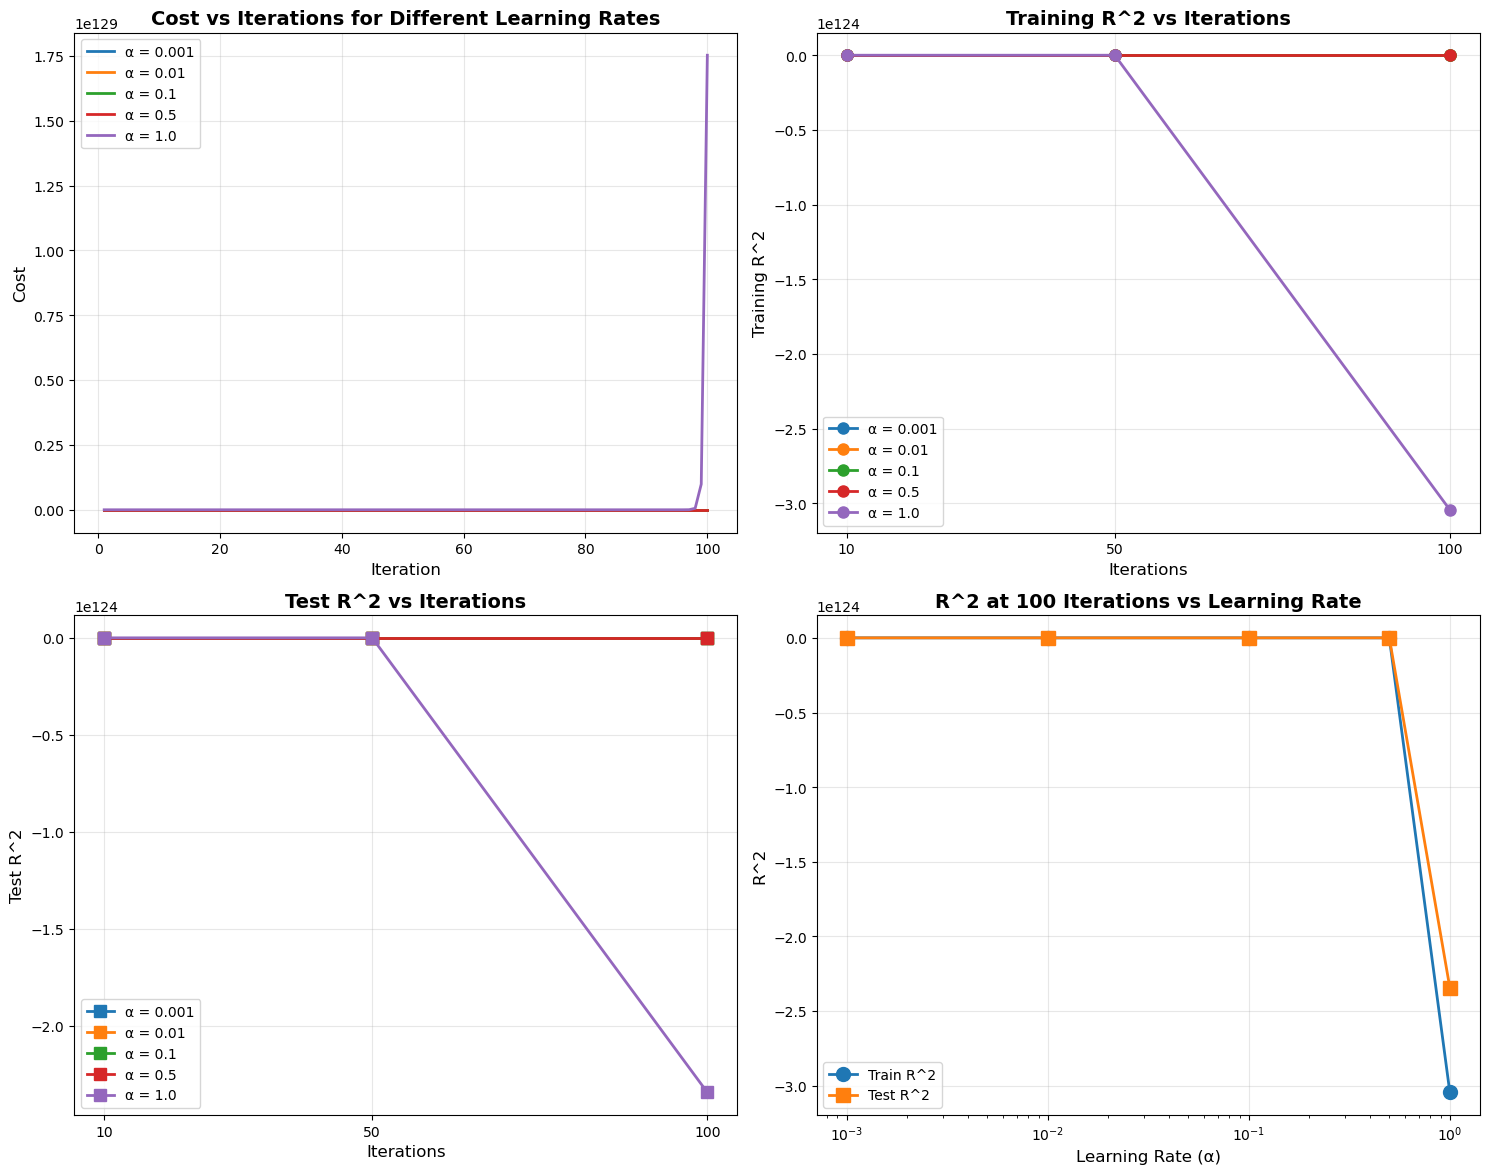

In [8]:
# learning rates to test
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
iterations_to_check = [10, 50, 100]
max_iterations = 100

# store results
results = []

for lr in learning_rates:
    # gradient descent
    theta_final, cost_history, theta_history = gradient_descent(
        X_train_scaled, y_train, lr, max_iterations, verbose=False
    )
    
    # at diff iterations
    for num_iter in iterations_to_check:
        theta = theta_history[num_iter]
        
        # training metrics
        y_train_pred = predict(X_train_scaled, theta)
        train_mse = mean_squared_error(y_train, y_train_pred)
        train_r2 = r2_score(y_train, y_train_pred)
        
        # test metrics
        y_test_pred = predict(X_test_scaled, theta)
        test_mse = mean_squared_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # store
        results.append({
            'Learning Rate': lr,
            'Iterations': num_iter,
            'Train MSE': train_mse,
            'Train R^2': train_r2,
            'Test MSE': test_mse,
            'Test R^2': test_r2,
            'Final Cost': cost_history[num_iter - 1]
        })
        
        print(f"  Iteration {num_iter}:")
        print(f"    Train MSE: {train_mse:.2f}, Train R^2: {train_r2:.2f}")
        print(f"    Test MSE: {test_mse:.2f}, Test R^2: {test_r2:.2f}")
        print(f"    Cost: {cost_history[num_iter - 1]:.2f}")
    
    print()

# results
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print()

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

valid_lrs = [lr for lr in learning_rates if lr <= 0.1]

# Plot 1: Cost vs Iterations for different learning rates
ax1 = axes[0, 0]
for lr in learning_rates:
    theta_final, cost_history, _ = gradient_descent(
        X_train_scaled, y_train, lr, max_iterations, verbose=False
    )
    ax1.plot(range(1, max_iterations + 1), cost_history, label=f'α = {lr}', linewidth=2)

ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Cost', fontsize=12)
ax1.set_title('Cost vs Iterations for Different Learning Rates', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Training R^2 vs Iterations
ax2 = axes[0, 1]
for lr in learning_rates:
    r2_values = results_df[results_df['Learning Rate'] == lr]['Train R^2'].values
    ax2.plot(iterations_to_check, r2_values, marker='o', label=f'α = {lr}', linewidth=2, markersize=8)

ax2.set_xlabel('Iterations', fontsize=12)
ax2.set_ylabel('Training R^2', fontsize=12)
ax2.set_title('Training R^2 vs Iterations', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(iterations_to_check)

# Plot 3: Test R^2 vs Iterations
ax3 = axes[1, 0]
for lr in learning_rates:
    r2_values = results_df[results_df['Learning Rate'] == lr]['Test R^2'].values
    ax3.plot(iterations_to_check, r2_values, marker='s', label=f'α = {lr}', linewidth=2, markersize=8)

ax3.set_xlabel('Iterations', fontsize=12)
ax3.set_ylabel('Test R^2', fontsize=12)
ax3.set_title('Test R^2 vs Iterations', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(iterations_to_check)

# Plot 4: Final R^2 at 100 iterations vs Learning Rate
ax4 = axes[1, 1]
final_results = results_df[results_df['Iterations'] == 100]
ax4.plot(final_results['Learning Rate'], final_results['Train R^2'], 
         marker='o', label='Train R^2', linewidth=2, markersize=10)
ax4.plot(final_results['Learning Rate'], final_results['Test R^2'], 
         marker='s', label='Test R^2', linewidth=2, markersize=10)
ax4.set_xlabel('Learning Rate (α)', fontsize=12)
ax4.set_ylabel('R^2', fontsize=12)
ax4.set_title('R^2 at 100 Iterations vs Learning Rate', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xscale('log')

plt.tight_layout()
plt.show()

The higher the learning rate, the more the model improves; however, once we get past 0.1 the model diverges. Below 0.1 is too slow or converges very slowly: 0.001 is too slow with negatives R^2 even after 100 iterations, 0.01 is slow but steady with R^2 becoming 0.43 after 100 iteration, 0.1 at 100 iterations is where the model converges with a Train MSE and R^2 at 31428 and 0.73 and a test set MSE and R^2 at 58892 and 0.65. Anything past that becomes more and more negative in terms of R^2 for both training and test data sets.

# *[A/C]* Problem 6: Ridge regularization (20 points)

In this problem, you will derive the optimal parameters for ridge regression and train ridge regression models with different regularization levels. In ridge regression, the loss function includes a regularization term:

$J(\theta) = \sum_{i=1}^N(h_{\theta}(x_i)-y_i)^2 + \lambda \sum_{j=1}^d \theta_j^2$

1. **[A]** Write the derivation of the closed form solution for parameter $\theta$ that minimizes the loss function $J(\theta)$ in ridge regression.
2. **[C]** Modify your implementation from Problem 5 to implement ridge regression with gradient descent.
3. **[C]** Simulate $N=1000$ values of random variable $X_i$, distributed uniformly on interval $[-2,2]$. Simulate the values of random variable       $Y_i = 1 + 2X_i + e_i$, where $e_i$ is drawn from a Gaussian distribution $N(0, 2)$. Fit this data with linear regression, and also with ridge regression
for different values of $\lambda \in \{1,10,100,1000,10000\}$. Print the slope, the MSE values, and the $R^2$ statistic for each case and write down some observations. What happens as the regularization parameter $\lambda$ increases?

# q6.1

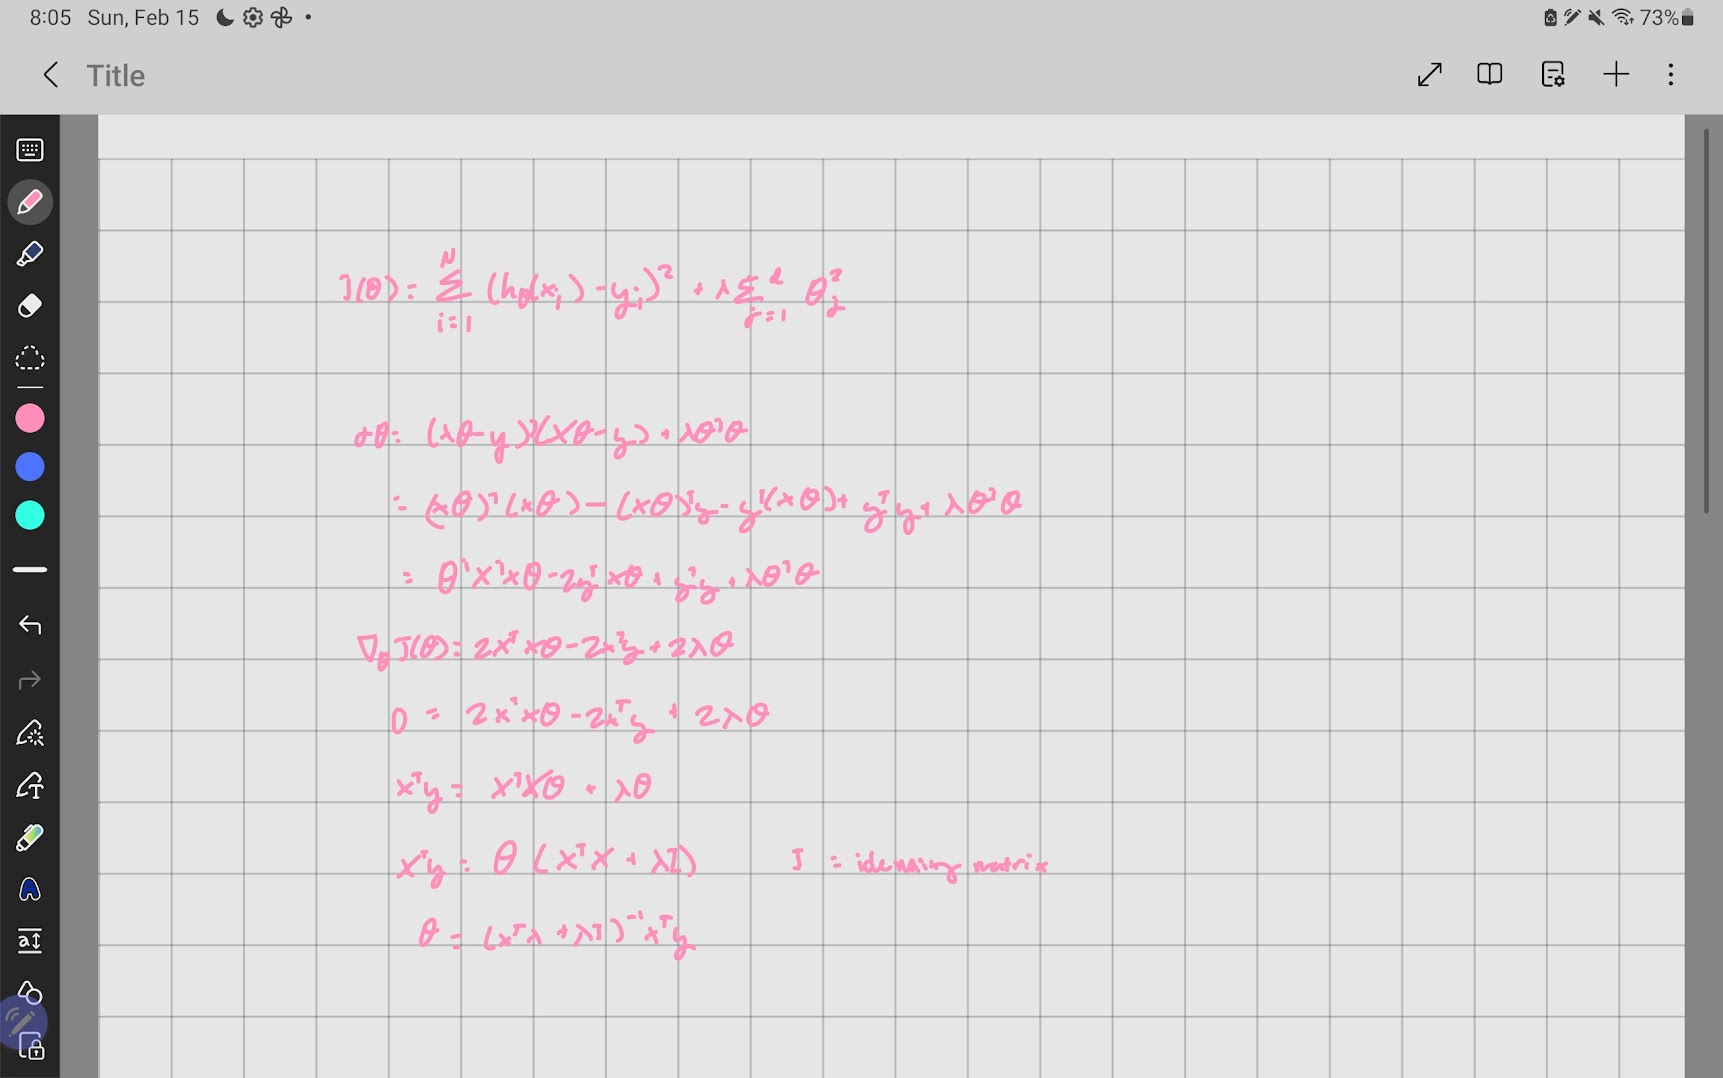

In [9]:
# q6.2

def compute_cost_ridge(X, y, theta, lambda_reg):
    n_samples = X.shape[0]
    
    # add intercept column
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X])
    
    # preds
    predictions = X_with_intercept @ theta
    
    # cost
    mse_cost = (1 / (2 * n_samples)) * np.sum((predictions - y) ** 2)
    reg_cost = (lambda_reg / (2 * n_samples)) * np.sum(theta[1:] ** 2)
    
    return mse_cost + reg_cost


def compute_gradient_ridge(X, y, theta, lambda_reg):
    n_samples = X.shape[0]
    
    # add intercept column
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X])
    
    # preds
    predictions = X_with_intercept @ theta
    
    # grad
    gradient = (1 / n_samples) * X_with_intercept.T @ (predictions - y)
    
    # regularization term
    gradient[1:] += (lambda_reg / n_samples) * theta[1:]
    
    return gradient


def gradient_descent_ridge(X, y, lambda_reg, learning_rate=0.01, num_iterations=1000):
    n_features = X.shape[1]
    theta = np.zeros(n_features + 1)
    
    for i in range(num_iterations):
        gradient = compute_gradient_ridge(X, y, theta, lambda_reg)
        theta = theta - learning_rate * gradient
    
    return theta


def ridge_regression_closed_form(X, y, lambda_reg):
    n_samples = X.shape[0]
    
    # add intercept column
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X])
    
    n_features = X_with_intercept.shape[1]

    I = np.eye(n_features)
    I[0, 0] = 0
    
    # closed form solution
    theta = np.linalg.inv(X_with_intercept.T @ X_with_intercept + lambda_reg * I) @ X_with_intercept.T @ y
    
    return theta


def predict_ridge(X, theta):
    n_samples = X.shape[0]
    ones = np.ones((n_samples, 1))
    X_with_intercept = np.hstack([ones, X])
    return X_with_intercept @ theta

Generated 1000 samples:
  X ~ Uniform[-2, 2]
  y = 1 + 2X + ε, where ε ~ N(0, 2)
  True parameters: θ₀ = 1, θ₁ = 2

λ =      0
  θ₀ (intercept) = 1.14  (true: 1.0)
  θ₁ (slope)     = 1.95  (true: 2.0)
  MSE            = 1.95
  R^2             = 0.73

λ =      1
  θ₀ (intercept) = 1.14  (true: 1.0)
  θ₁ (slope)     = 1.94  (true: 2.0)
  MSE            = 1.95
  R^2             = 0.73

λ =     10
  θ₀ (intercept) = 1.14  (true: 1.0)
  θ₁ (slope)     = 1.93  (true: 2.0)
  MSE            = 1.95
  R^2             = 0.73

λ =    100
  θ₀ (intercept) = 1.13  (true: 1.0)
  θ₁ (slope)     = 1.81  (true: 2.0)
  MSE            = 1.97
  R^2             = 0.72

λ =   1000
  θ₀ (intercept) = 1.11  (true: 1.0)
  θ₁ (slope)     = 1.12  (true: 2.0)
  MSE            = 2.87
  R^2             = 0.60

λ =  10000
  θ₀ (intercept) = 1.07  (true: 1.0)
  θ₁ (slope)     = 0.23  (true: 2.0)
  MSE            = 5.95
  R^2             = 0.16

    λ  Intercept (θ₀)  Slope (θ₁)      MSE      R^2
    0        1.137727 

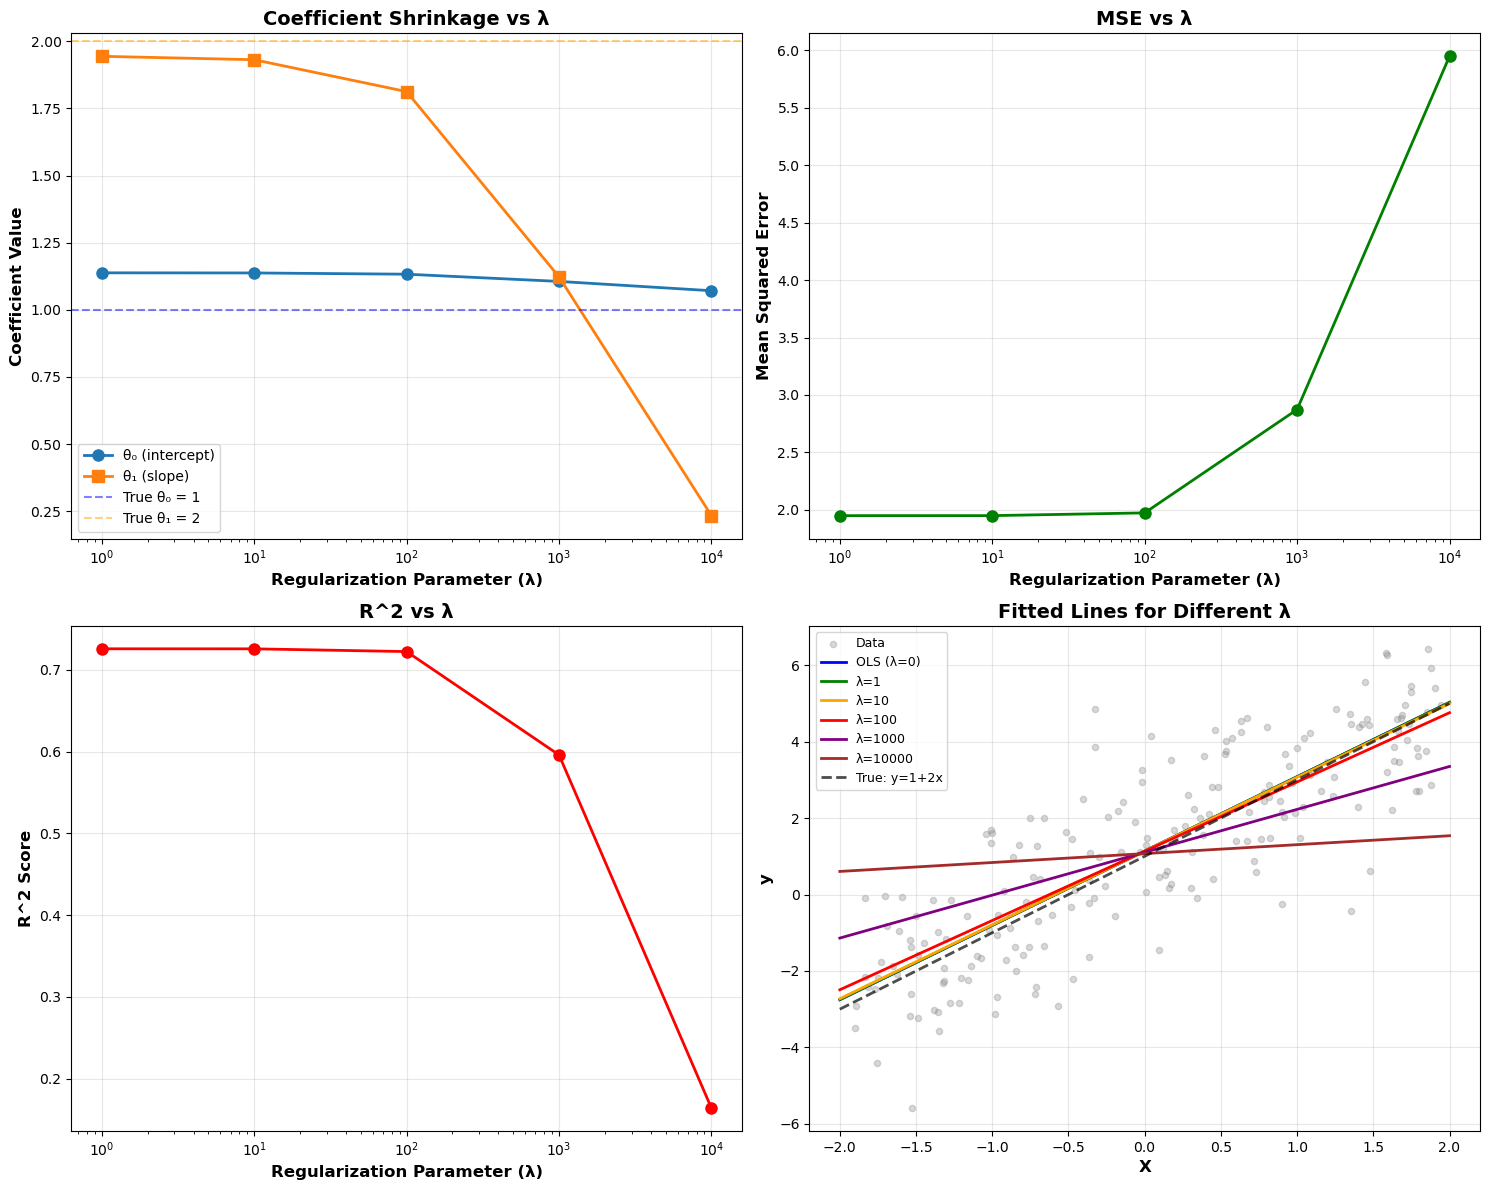

In [10]:
# q6.3

np.random.seed(42)

# simulate data
N = 1000
X = np.random.uniform(-2, 2, N)
epsilon = np.random.normal(0, np.sqrt(2), N)  # N(0, 2) means variance=2, std=sqrt(2)
y = 1 + 2*X + epsilon

print(f"Generated {N} samples:")
print(f"  X ~ Uniform[-2, 2]")
print(f"  y = 1 + 2X + ε, where ε ~ N(0, 2)")
print(f"  True parameters: θ₀ = 1, θ₁ = 2")
print()

# reshape X for compatibility
X_train = X.reshape(-1, 1)

# diff lambda values
lambda_values = [0, 1, 10, 100, 1000, 10000]

results = []

for lambda_reg in lambda_values:
    # train using closed form solution
    theta = ridge_regression_closed_form(X_train, y, lambda_reg)
    
    # preds
    y_pred = predict_ridge(X_train, theta)
    
    # calculate metrics
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    # store results
    results.append({
        'λ': lambda_reg,
        'Intercept (θ₀)': theta[0],
        'Slope (θ₁)': theta[1],
        'MSE': mse,
        'R^2': r2
    })
    
    print(f"λ = {lambda_reg:>6}")
    print(f"  θ₀ (intercept) = {theta[0]:.2f}  (true: 1.0)")
    print(f"  θ₁ (slope)     = {theta[1]:.2f}  (true: 2.0)")
    print(f"  MSE            = {mse:.2f}")
    print(f"  R^2             = {r2:.2f}")
    print()

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print()

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: coefficient vals vs λ
ax1 = axes[0, 0]
ax1.semilogx(results_df['λ'][1:], results_df['Intercept (θ₀)'][1:], 
             marker='o', label='θ₀ (intercept)', linewidth=2, markersize=8)
ax1.semilogx(results_df['λ'][1:], results_df['Slope (θ₁)'][1:], 
             marker='s', label='θ₁ (slope)', linewidth=2, markersize=8)
ax1.axhline(y=1, color='blue', linestyle='--', alpha=0.5, label='True θ₀ = 1')
ax1.axhline(y=2, color='orange', linestyle='--', alpha=0.5, label='True θ₁ = 2')
ax1.set_xlabel('Regularization Parameter (λ)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Coefficient Value', fontsize=12, fontweight='bold')
ax1.set_title('Coefficient Shrinkage vs λ', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: MSE vs λ
ax2 = axes[0, 1]
ax2.semilogx(results_df['λ'][1:], results_df['MSE'][1:], 
             marker='o', linewidth=2, markersize=8, color='green')
ax2.set_xlabel('Regularization Parameter (λ)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
ax2.set_title('MSE vs λ', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: R^2 vs λ
ax3 = axes[1, 0]
ax3.semilogx(results_df['λ'][1:], results_df['R^2'][1:], 
             marker='o', linewidth=2, markersize=8, color='red')
ax3.set_xlabel('Regularization Parameter (λ)', fontsize=12, fontweight='bold')
ax3.set_ylabel('R^2 Score', fontsize=12, fontweight='bold')
ax3.set_title('R^2 vs λ', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: fitted lines for different λ
ax4 = axes[1, 1]

# data points
sample_indices = np.random.choice(N, 200, replace=False)
ax4.scatter(X[sample_indices], y[sample_indices], alpha=0.3, s=20, color='gray', label='Data')

# fitted lines for diff λ values
x_line = np.linspace(-2, 2, 100).reshape(-1, 1)
colors_plot = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

for i, lambda_reg in enumerate(lambda_values):
    theta = ridge_regression_closed_form(X_train, y, lambda_reg)
    y_line = predict_ridge(x_line, theta)
    
    if lambda_reg == 0:
        label = f'OLS (λ=0)'
    else:
        label = f'λ={lambda_reg}'
    
    ax4.plot(x_line, y_line, linewidth=2, label=label, color=colors_plot[i])

# true line
ax4.plot(x_line, 1 + 2*x_line, 'k--', linewidth=2, label='True: y=1+2x', alpha=0.7)

ax4.set_xlabel('X', fontsize=12, fontweight='bold')
ax4.set_ylabel('y', fontsize=12, fontweight='bold')
ax4.set_title('Fitted Lines for Different λ', fontsize=14, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

As λ increase from 0 t 10k, the slope coefficient shrinks from 1.95 toward 0 (0.23). MSE increases greatly and R^2 drops from 0.73 to 0.16. The more regularization that occurs more bias and causes for underfitting are introduced.

## Helpful resources 
Don't forget to cite websites which helped you solve a problem in a unique way.  You can do this in markdown near the code or with a simple one-line comment inside the code cell, or you can list them below. 

You do not need to cite the official python documentation.


https://www.geeksforgeeks.org/machine-learning/how-to-implement-a-gradient-descent-in-python-to-find-a-local-minimum/
https://medium.com/@maxwienandts/regularization-in-linear-regression-a-deep-dive-into-ridge-and-lasso-3d2853e5e2b0
https://medium.com/@heyamit10/polynomial-regression-from-scratch-in-python-3c96a801d992
https://towardsdatascience.com/normal-equation-in-python-the-closed-form-solution-for-linear-regression-13df33f9ad71/